# Singapore Jobs Analytics: Skills Roadmap for Jobseekers and Career Switchers

**Target users:** jobseekers and career switchers in Singapore.  
**Core question:** Which skills should I learn to improve employability?

This notebook turns the CSV job-posting data into a simple data-product prototype. It covers the assignment sections from the README: business case, data handling, exploratory analysis, and a dashboard-style walkthrough focused on in-demand skills, salary trends, entry-level vs senior-level opportunities, and role pathways.


## 1. Business Case

- **Scenario:** A career coach or self-service career guidance team wants to help jobseekers choose skills that improve employability in Singapore.
- **Objective:** Identify skills and role families with strong demand, healthy salaries, accessible entry-level opportunities, and realistic progression paths.
- **Value for users:** Jobseekers can compare skills by demand and salary, see whether roles are entry-friendly or senior-heavy, and prioritize learning pathways with evidence from market postings.

**Success criteria for the dashboard:** A user should be able to answer:  
1. What skills are most requested in job postings?  
2. Which skills are linked to stronger salaries?  
3. Which role families have enough entry-level openings?  
4. What skills appear along entry, mid, and senior role pathways?


## 2. Setup

The notebook uses common Python data tools. The CSV is large, so the loading step selects only the columns needed for this career-switcher use case.


In [1]:
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("SGJobData.csv") / "SGJobData.csv"
assert DATA_PATH.exists(), f"Could not find data file at {DATA_PATH.resolve()}"


## 3. Load the CSV

Only the columns needed for the analysis are loaded. This keeps memory use manageable while still preserving the signals required for the dashboard: posting date, title, category, seniority, experience, salary, views, applications, and vacancies.


In [2]:
usecols = [
    "categories",
    "employmentTypes",
    "metadata_jobPostId",
    "metadata_newPostingDate",
    "metadata_totalNumberJobApplication",
    "metadata_totalNumberOfView",
    "minimumYearsExperience",
    "numberOfVacancies",
    "positionLevels",
    "postedCompany_name",
    "salary_maximum",
    "salary_minimum",
    "salary_type",
    "status_jobStatus",
    "title",
    "average_salary",
]

df_raw = pd.read_csv(DATA_PATH, usecols=usecols)
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]:,} columns")
df_raw.head()


Loaded 1,048,585 rows and 16 columns


,categories,employmentTypes,metadata_jobPostId,metadata_newPostingDate,metadata_totalNumberJobApplication,metadata_totalNumberOfView,minimumYearsExperience,numberOfVacancies,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,MCF-2023-0252866,2023-04-08,5,151,0,1,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,MCF-2023-0273977,2023-04-08,0,55,2,2,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,MCF-2023-0273994,2023-04-08,7,99,3,1,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,MCF-2023-0273991,2023-04-08,6,113,8,1,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,MCF-2023-0273976,2023-04-08,3,99,2,3,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,Closed,Sales / Admin Cordinator,2900.0


## 4. Cleaning and Feature Engineering

Key decisions:

- Keep **monthly salary** postings because mixed salary periods would distort comparisons.
- Remove salary rows with missing, zero, negative, or implausibly high monthly values.
- Parse posting dates to support monthly trend charts.
- Extract the first listed category as the primary job category.
- Build career-switcher features: role family, seniority band, salary band, and title-based skill tags.

**Important limitation:** The CSV does not include full job descriptions. Skill extraction is therefore based mainly on job titles, which means the skill counts are conservative and should be interpreted as visible skill signals rather than complete requirements.


In [3]:
def parse_primary_category(value):
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list) and parsed:
            first = parsed[0]
            if isinstance(first, dict):
                return first.get("category", "Unknown")
    except Exception:
        pass
    return "Unknown"


def classify_seniority(row):
    level = str(row.get("positionLevels", "")).lower()
    title = str(row.get("title", "")).lower()
    years = row.get("minimumYearsExperience", np.nan)

    if pd.isna(years):
        years = 0

    if re.search(r"intern|trainee|graduate|fresh|entry", title) or "fresh" in level or "junior" in level:
        return "Entry Level"
    if years <= 1:
        return "Entry Level"
    if any(token in level for token in ["manager", "management"]) or re.search(r"manager|lead|principal|head|director", title):
        return "Manager & Lead"
    if "senior" in level or "senior" in title or years >= 5:
        return "Senior"
    return "Mid Level"


role_patterns = {
    "Data & Analytics": r"data analyst|data scientist|analytics|business intelligence|bi analyst|machine learning|ai engineer|data engineer",
    "Software Engineering": r"software|developer|programmer|full stack|frontend|backend|java|\.net|mobile app|web developer",
    "Cybersecurity": r"cyber|security analyst|soc analyst|information security|penetration|governance risk|grc",
    "Cloud / DevOps": r"cloud|devops|site reliability|sre|platform engineer|infrastructure engineer",
    "Product / Project": r"product manager|project manager|scrum master|programme manager|program manager|business project",
    "Business / Strategy": r"business analyst|strategy|consultant|transformation|process analyst",
    "UX / Design": r"ux|ui|designer|figma|product design|graphic designer|visual designer",
    "Digital Marketing": r"digital marketing|seo|sem|performance marketing|social media|content marketer",
    "Finance / Accounting": r"account|audit|finance|tax|treasury|payroll|bookkeeper",
    "HR / Talent": r"human resource|hr |recruit|talent acquisition|learning and development",
    "Sales / Customer": r"sales|business development|customer service|account manager|relationship manager",
    "Operations / Admin": r"operations|admin|administrator|office manager|coordinator|executive assistant",
    "Supply Chain / Logistics": r"logistic|supply chain|warehouse|procurement|purchasing|planner",
    "Engineering / Technical": r"engineer|technician|mechanical|electrical|civil|manufacturing|maintenance",
    "Healthcare / Life Sciences": r"nurse|clinic|healthcare|pharmac|laboratory|scientist|therapist",
    "Education / Training": r"teacher|trainer|lecturer|educator|curriculum|instructor",
}


def classify_role_family(title):
    text = str(title).lower()
    for family, pattern in role_patterns.items():
        if re.search(pattern, text):
            return family
    return "Other / General"


skill_patterns = {
    "Python": r"\bpython\b",
    "SQL": r"\bsql\b|database|data warehouse",
    "Excel": r"\bexcel\b|spreadsheet",
    "Power BI": r"power\s*bi|powerbi",
    "Tableau": r"tableau",
    "Data Analytics": r"data analy|analytics|business intelligence|\bbi\b",
    "Machine Learning / AI": r"machine learning|\bai\b|artificial intelligence|deep learning|nlp",
    "Java": r"\bjava\b",
    "JavaScript": r"javascript|\bjs\b|react|angular|vue|node",
    ".NET / C#": r"\.net|c#|c sharp|asp\.net",
    "Cloud": r"cloud|aws|azure|gcp|google cloud",
    "AWS": r"\baws\b|amazon web services",
    "Azure": r"azure",
    "DevOps": r"devops|ci/cd|cicd|site reliability|sre",
    "Docker / Kubernetes": r"docker|kubernetes|\bk8s\b|container",
    "Cybersecurity": r"cyber|information security|network security|penetration|soc analyst|grc",
    "SAP": r"\bsap\b",
    "Salesforce": r"salesforce",
    "Project Management": r"project management|project manager|pmp|programme manager|program manager",
    "Agile / Scrum": r"agile|scrum",
    "Accounting": r"accounting|audit|tax|bookkeeping|accounts payable|accounts receivable",
    "Digital Marketing": r"digital marketing|seo|sem|performance marketing|social media",
    "UI/UX / Figma": r"\bux\b|\bui\b|figma|product design",
    "Communication": r"communication|stakeholder|presentation",
    "Mandarin": r"mandarin|chinese speaking",
}

compiled_skill_patterns = {skill: re.compile(pattern, flags=re.IGNORECASE) for skill, pattern in skill_patterns.items()}


def extract_skills(title):
    text = str(title)
    return [skill for skill, pattern in compiled_skill_patterns.items() if pattern.search(text)]


df = df_raw.copy()
df["posting_date"] = pd.to_datetime(df["metadata_newPostingDate"], errors="coerce")
df["posting_month"] = df["posting_date"].dt.to_period("M").dt.to_timestamp()
df["primary_category"] = df["categories"].apply(parse_primary_category)
df["role_family"] = df["title"].apply(classify_role_family)
df["seniority"] = df.apply(classify_seniority, axis=1)
df["skills"] = df["title"].apply(extract_skills)
df["skill_count"] = df["skills"].str.len()
df["competition_per_vacancy"] = df["metadata_totalNumberJobApplication"] / df["numberOfVacancies"].replace(0, np.nan)

raw_full_duplicate_rows = int(df_raw.duplicated().sum())
raw_duplicate_job_id_rows = int(
    (df_raw["metadata_jobPostId"].notna() & df_raw["metadata_jobPostId"].duplicated()).sum()
)

salary_mask = (
    df["salary_type"].eq("Monthly")
    & df["posting_date"].notna()
    & df["average_salary"].notna()
    & df["average_salary"].between(500, 50000)
    & df["salary_minimum"].between(0, 50000)
    & df["salary_maximum"].between(0, 70000)
)
df = df.loc[salary_mask].copy()
rows_after_salary_filter = len(df)

full_duplicate_rows_after_salary_filter = int(df[usecols].duplicated().sum())
df = df.drop_duplicates(subset=usecols).copy()
rows_after_full_duplicate_removal = len(df)

duplicate_job_id_mask = df["metadata_jobPostId"].notna() & df["metadata_jobPostId"].duplicated()
duplicate_job_id_rows_after_salary_filter = int(duplicate_job_id_mask.sum())
df = df.loc[~duplicate_job_id_mask].copy()
rows_after_duplicate_cleaning = len(df)

df["salary_band"] = pd.cut(
    df["average_salary"],
    bins=[0, 3000, 5000, 8000, 12000, np.inf],
    labels=["<$3k", "$3k-$5k", "$5k-$8k", "$8k-$12k", "$12k+"],
)

print(f"Rows after cleaning: {len(df):,}")
df[["title", "primary_category", "role_family", "seniority", "average_salary", "skills"]].head(10)


Rows after cleaning: 1,036,725


,title,primary_category,role_family,seniority,average_salary,skills
0,Food Technologist - Clementi | Entry Level | U...,Environment / Health,Other / General,Entry-level,2400.0,[]
1,"Software Engineer (Fab Support) (Java, CIM, Up...",Information Technology,Software Engineering,Mid-level,4750.0,[Java]
2,Senior Technician,Repair and Maintenance,Engineering / Technical,Senior-level,4200.0,[]
3,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",Information Technology,Software Engineering,Senior-level,7500.0,[.NET / C#]
4,Sales / Admin Cordinator,Admin / Secretarial,Sales / Customer,Mid-level,2900.0,[]
5,Software Support Engineer,Consulting,Software Engineering,Entry-level,5000.0,[]
6,Urgent Hiring!!! Business Development Manager ...,Information Technology,Sales / Customer,Senior-level,9000.0,[]
7,IT Security Engineer (Maritime/ Cloud Security),Security and Investigation,Cloud / DevOps,Senior-level,6750.0,[Cloud]
8,Assistant Sales Manager (Hunter Role)- Up to $...,Accounting / Auditing / Taxation,Sales / Customer,Entry-level,4250.0,[]
9,"Car Leasing, RM – West|Entry Level | Up to Bas...",Consulting,Other / General,Entry-level,4750.0,[]


## 5. Data Quality Snapshot

This section documents the main data quality checks used in the cleaning phase: missing values, duplicate records, salary outliers, and before-vs-after row counts. The goal is to show what was removed and why before the dashboard analysis begins.


In [4]:
quality_summary = pd.DataFrame({
    "check": [
        "Rows loaded",
        "Rows after salary/date filters",
        "Rows after duplicate cleaning",
        "Rows removed by salary/date filters",
        "Full duplicate rows in raw data",
        "Duplicate job IDs in raw data",
        "Full duplicate rows after salary/date filters",
        "Duplicate job IDs after salary/date filters",
        "Clean salary range",
        "Posting date coverage",
        "Unique companies after cleaning",
        "Postings with visible skill tag",
        "Share with visible skill tag",
    ],
    "result": [
        f"{len(df_raw):,}",
        f"{rows_after_salary_filter:,}",
        f"{len(df):,}",
        f"{len(df_raw) - rows_after_salary_filter:,}",
        f"{raw_full_duplicate_rows:,}",
        f"{raw_duplicate_job_id_rows:,}",
        f"{full_duplicate_rows_after_salary_filter:,}",
        f"{duplicate_job_id_rows_after_salary_filter:,}",
        f"SGD {df['average_salary'].min():,.0f} to SGD {df['average_salary'].max():,.0f}",
        f"{df['posting_date'].min().date()} to {df['posting_date'].max().date()}",
        f"{df['postedCompany_name'].nunique():,}",
        f"{(df['skill_count'] > 0).sum():,}",
        f"{(df['skill_count'] > 0).mean():.1%}",
    ]
})
quality_summary


                                        check                   result
                                  Rows loaded                1,048,585
               Rows after salary/date filters                1,036,725
                Rows after duplicate cleaning                1,036,725
          Rows removed by salary/date filters                   11,860
              Full duplicate rows in raw data                    3,987
                Duplicate job IDs in raw data                        0
Full duplicate rows after salary/date filters                        0
  Duplicate job IDs after salary/date filters                        0
                           Clean salary range    SGD 500 to SGD 50,000
                        Posting date coverage 2023-03-28 to 2024-05-29
              Unique companies after cleaning                   52,917
              Postings with visible skill tag                   93,533
                 Share with visible skill tag                     9.0%

In [5]:
critical_columns = [
    "metadata_jobPostId",
    "metadata_newPostingDate",
    "title",
    "postedCompany_name",
    "salary_type",
    "salary_minimum",
    "salary_maximum",
    "average_salary",
    "minimumYearsExperience",
    "numberOfVacancies",
]

missing_summary = pd.DataFrame({
    "column": critical_columns,
    "raw_missing_percent": df_raw[critical_columns].isna().mean().mul(100).round(2).values,
    "cleaned_missing_percent": df[critical_columns].isna().mean().mul(100).round(2).values,
}).sort_values("raw_missing_percent", ascending=False)

missing_summary


                 column  raw_missing_percent  cleaned_missing_percent
     metadata_jobPostId                 0.38                      0.0
metadata_newPostingDate                 0.38                      0.0
                  title                 0.38                      0.0
     postedCompany_name                 0.38                      0.0
            salary_type                 0.38                      0.0
         salary_minimum                 0.00                      0.0
         salary_maximum                 0.00                      0.0
         average_salary                 0.00                      0.0
 minimumYearsExperience                 0.00                      0.0
      numberOfVacancies                 0.00                      0.0

### Data quality interpretation

- **Missing data:** Critical fields such as job ID, posting date, title, company, and salary type had a small amount of missingness in the raw file. The cleaning filters remove rows without valid posting dates and valid monthly salary values.
- **Duplicates:** The notebook checks both full-row duplicates and repeated `metadata_jobPostId` values. Duplicate removal is included after salary/date filtering so repeated records cannot inflate demand counts.
- **Outliers:** Salary comparisons keep monthly salary postings only and restrict salary values to plausible bounds: average salary from SGD 500 to SGD 50,000, minimum salary from SGD 0 to SGD 50,000, and maximum salary from SGD 0 to SGD 70,000.


## 6. Market Overview

These charts provide the dashboard's opening view: major role families, seniority mix, and salary distribution.


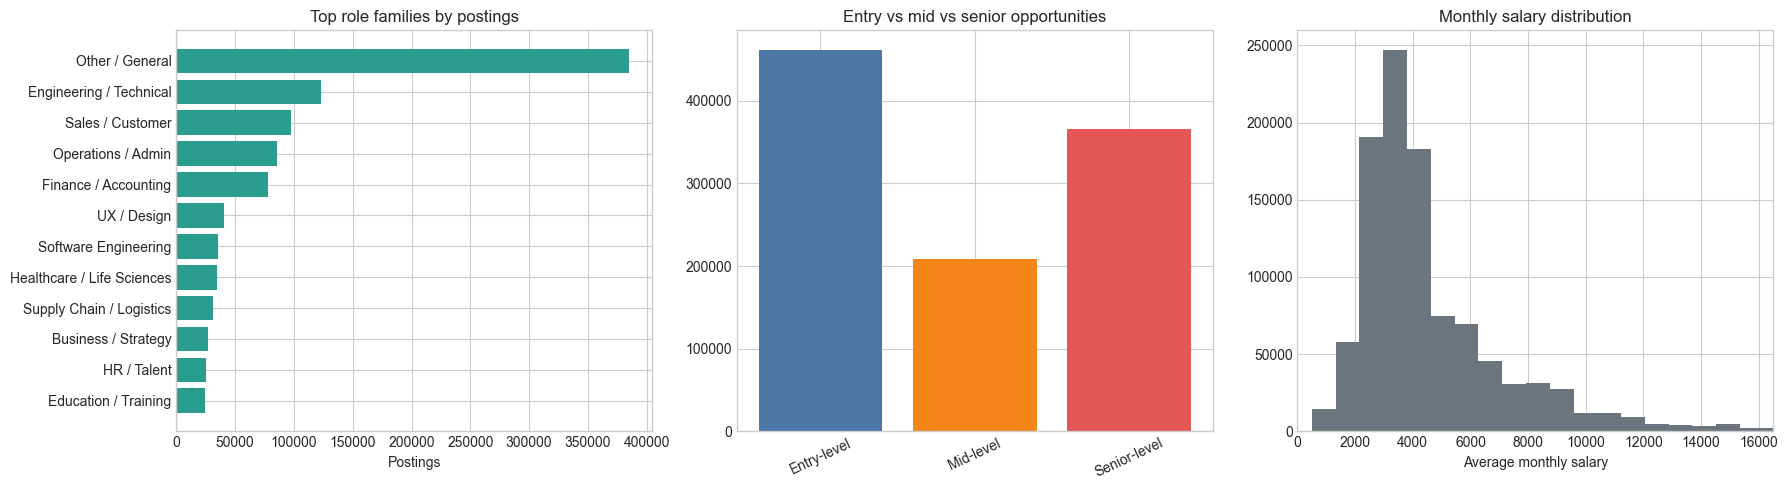

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

role_counts = df["role_family"].value_counts().head(12).sort_values()
axes[0].barh(role_counts.index, role_counts.values, color="#2a9d8f")
axes[0].set_title("Top role families by postings")
axes[0].set_xlabel("Postings")

seniority_counts = df["seniority"].value_counts().reindex(["Entry Level", "Mid Level", "Senior", "Manager & Lead"])
axes[1].bar(seniority_counts.index, seniority_counts.values, color=["#4c78a8", "#f58518", "#e45756"])
axes[1].set_title("Entry vs mid vs senior opportunities")
axes[1].tick_params(axis="x", rotation=25)

axes[2].hist(df["average_salary"], bins=60, color="#6c757d")
axes[2].set_xlim(0, df["average_salary"].quantile(0.99))
axes[2].set_title("Monthly salary distribution")
axes[2].set_xlabel("Average monthly salary")

plt.tight_layout()
plt.show()


## 7. In-Demand Skills

A skill is treated as in demand when it appears often in job titles. The table also includes median salary, entry-level share, views, applications, and competition per vacancy.


In [8]:
skills_long = (
    df.loc[df["skill_count"] > 0, [
        "metadata_jobPostId", "title", "role_family", "seniority", "posting_month",
        "average_salary", "metadata_totalNumberJobApplication", "metadata_totalNumberOfView",
        "numberOfVacancies", "competition_per_vacancy", "skills"
    ]]
    .explode("skills")
    .rename(columns={"skills": "skill"})
)

skill_summary = (
    skills_long
    .groupby("skill")
    .agg(
        postings=("metadata_jobPostId", "nunique"),
        median_salary=("average_salary", "median"),
        average_salary=("average_salary", "mean"),
        entry_postings=("seniority", lambda s: (s == "Entry Level").sum()),
        senior_postings=("seniority", lambda s: (s == "Senior").sum()),
        avg_views=("metadata_totalNumberOfView", "mean"),
        avg_applications=("metadata_totalNumberJobApplication", "mean"),
        competition_per_vacancy=("competition_per_vacancy", "mean"),
    )
    .reset_index()
)

skill_summary["entry_share"] = skill_summary["entry_postings"] / skill_summary["postings"]
skill_summary["senior_share"] = skill_summary["senior_postings"] / skill_summary["postings"]

for col in ["postings", "median_salary", "entry_share"]:
    min_v = skill_summary[col].min()
    max_v = skill_summary[col].max()
    skill_summary[f"{col}_scaled"] = (skill_summary[col] - min_v) / (max_v - min_v) if max_v > min_v else 0

skill_summary["employability_score"] = (
    0.50 * skill_summary["postings_scaled"]
    + 0.30 * skill_summary["median_salary_scaled"]
    + 0.20 * skill_summary["entry_share_scaled"]
)

skill_summary = skill_summary.sort_values("employability_score", ascending=False)
skill_summary[[
    "skill", "postings", "median_salary", "entry_share", "senior_share",
    "avg_views", "avg_applications", "competition_per_vacancy", "employability_score"
]].head(20)


,skill,postings,median_salary,entry_share,senior_share,avg_views,avg_applications,competition_per_vacancy,employability_score
18,Project Management,16498,7000.0,0.084374,0.895321,32.270215,3.707783,2.848406,0.705912
2,Accounting,15821,4000.0,0.435308,0.415840,23.502560,1.502117,1.230505,0.635457
10,Digital Marketing,14428,3750.0,0.511020,0.266011,23.183601,2.157541,1.709680,0.604749
5,Cloud,10331,5000.0,0.384571,0.407027,19.173459,1.426483,1.137634,0.506783
15,Machine Learning / AI,2235,8750.0,0.381208,0.383893,30.108725,2.417897,1.784405,0.471833
20,SAP,5871,6750.0,0.216999,0.584228,18.688639,1.204905,0.899134,0.412004
13,Java,4505,7500.0,0.137403,0.631964,19.221532,1.104329,0.616301,0.385398
7,Cybersecurity,4826,7000.0,0.175715,0.590344,27.824700,2.618732,1.730020,0.379951
9,DevOps,3103,8000.0,0.126329,0.563004,18.816307,1.086690,0.735725,0.367170
0,.NET / C#,3341,6700.0,0.304101,0.440587,19.371446,1.144867,0.683882,0.361835


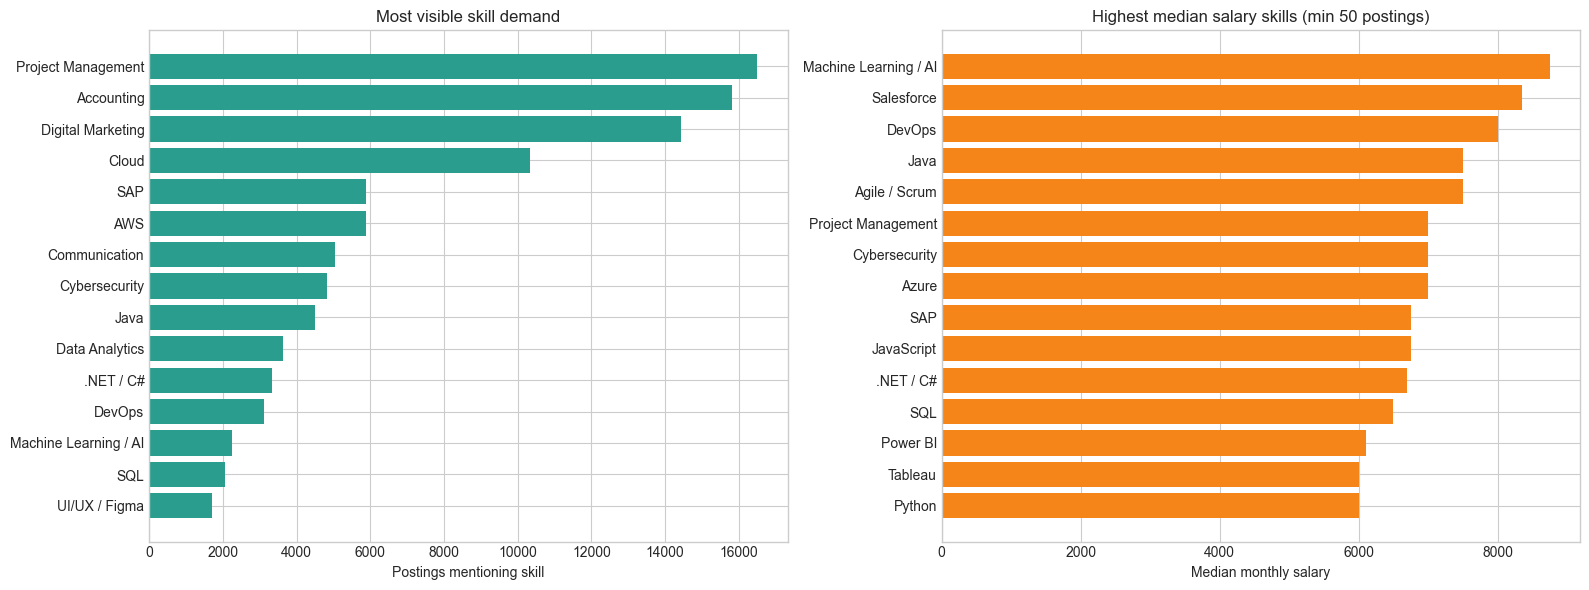

In [9]:
top_demand = skill_summary.sort_values("postings", ascending=False).head(15).sort_values("postings")
top_salary = skill_summary[skill_summary["postings"] >= 50].sort_values("median_salary", ascending=False).head(15).sort_values("median_salary")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_demand["skill"], top_demand["postings"], color="#2a9d8f")
axes[0].set_title("Most visible skill demand")
axes[0].set_xlabel("Postings mentioning skill")

axes[1].barh(top_salary["skill"], top_salary["median_salary"], color="#f58518")
axes[1].set_title("Highest median salary skills (min 50 postings)")
axes[1].set_xlabel("Median monthly salary")

plt.tight_layout()
plt.show()


## 8. Salary Trends Over Time

This view helps users see whether a skill's salary signal is stable, rising, or noisy. Skills with very few monthly postings may fluctuate heavily.


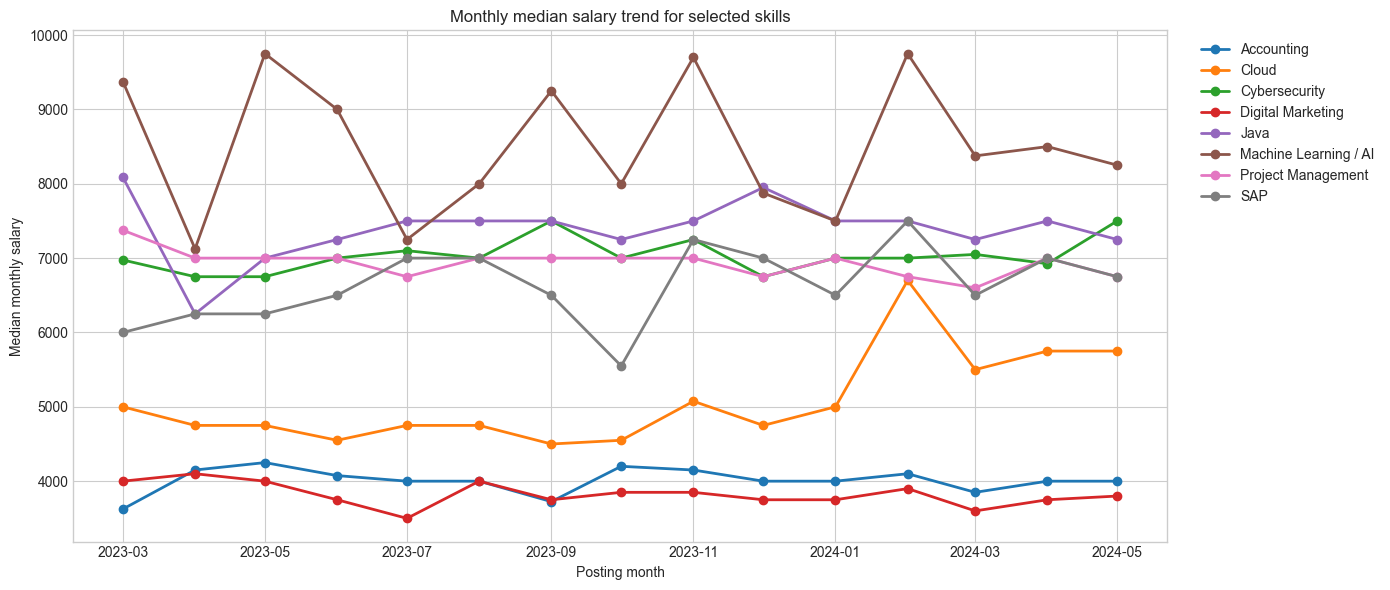

In [10]:
selected_skills = skill_summary.head(8)["skill"].tolist()
monthly_skill_salary = (
    skills_long[skills_long["skill"].isin(selected_skills)]
    .groupby(["posting_month", "skill"])
    .agg(postings=("metadata_jobPostId", "nunique"), median_salary=("average_salary", "median"))
    .reset_index()
)
monthly_skill_salary = monthly_skill_salary[monthly_skill_salary["postings"] >= 5]

fig, ax = plt.subplots(figsize=(14, 6))
for skill, group in monthly_skill_salary.groupby("skill"):
    ax.plot(group["posting_month"], group["median_salary"], marker="o", linewidth=2, label=skill)
ax.set_title("Monthly median salary trend for selected skills")
ax.set_xlabel("Posting month")
ax.set_ylabel("Median monthly salary")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 9. Entry-Level vs Senior-Level Opportunities

For career switchers, a high salary skill is less useful if most postings require senior experience. This chart compares opportunity mix by skill.


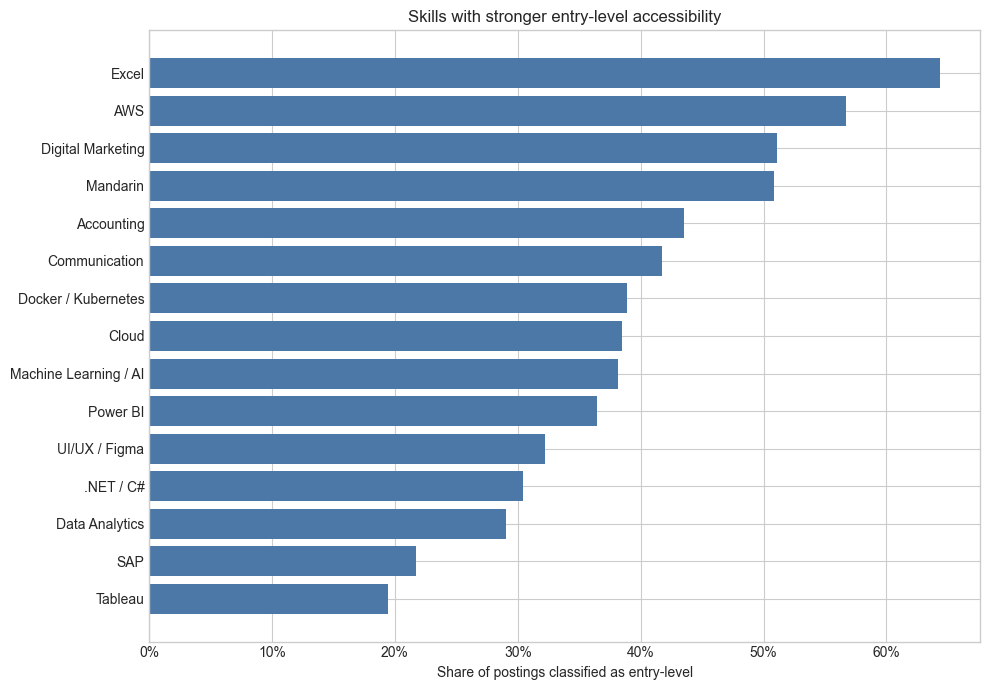

,skill,postings,median_salary,entry_share,senior_share
23,Tableau,180,6000.0,0.194444,0.355556
20,SAP,5871,6750.0,0.216999,0.584228
8,Data Analytics,3623,6000.0,0.290367,0.468120
0,.NET / C#,3341,6700.0,0.304101,0.440587
24,UI/UX / Figma,1696,5250.0,0.321934,0.396816
17,Power BI,505,6100.0,0.364356,0.502970
15,Machine Learning / AI,2235,8750.0,0.381208,0.383893
5,Cloud,10331,5000.0,0.384571,0.407027
11,Docker / Kubernetes,556,4500.0,0.388489,0.354317
6,Communication,5038,4050.0,0.417626,0.411274


In [11]:
entry_view = (
    skill_summary[skill_summary["postings"] >= 50]
    .sort_values("entry_share", ascending=False)
    .head(15)
    .sort_values("entry_share")
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(entry_view["skill"], entry_view["entry_share"], color="#4c78a8")
ax.set_title("Skills with stronger entry-level accessibility")
ax.set_xlabel("Share of postings classified as entry-level")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

entry_view[["skill", "postings", "median_salary", "entry_share", "senior_share"]]


## 10. Role Pathways

This section summarises what a jobseeker might learn as they move from entry-level to senior-level roles within a role family. It shows posting volume, median salary, and the most visible skills at each level.


In [12]:
def top_skills_for_group(group, n=5):
    values = group.explode("skills")["skills"].dropna()
    if values.empty:
        return "No visible skill tags in title"
    return ", ".join(values.value_counts().head(n).index)

pathway_summary = (
    df.groupby(["role_family", "seniority"])
    .apply(lambda g: pd.Series({
        "postings": g["metadata_jobPostId"].nunique(),
        "median_salary": g["average_salary"].median(),
        "top_visible_skills": top_skills_for_group(g),
    }))
    .reset_index()
)

pathway_summary = pathway_summary.sort_values(["role_family", "seniority"])
pathway_summary.head(30)


,role_family,seniority,postings,median_salary,top_visible_skills
0,Business / Strategy,Entry-level,10996,3750.0,"SAP, Accounting, Digital Marketing, Agile / Sc..."
1,Business / Strategy,Mid-level,4769,5500.0,"SAP, Agile / Scrum, Salesforce, Accounting, SQL"
2,Business / Strategy,Senior-level,11201,8500.0,"SAP, Accounting, Salesforce, Power BI, Agile /..."
3,Cloud / DevOps,Entry-level,1188,5250.0,"Cloud, DevOps, AWS, Azure, Communication"
4,Cloud / DevOps,Mid-level,2065,6500.0,"Cloud, DevOps, AWS, Azure, SQL"
5,Cloud / DevOps,Senior-level,4408,9000.0,"Cloud, DevOps, AWS, Azure, Project Management"
6,Cybersecurity,Entry-level,765,4750.0,"Cybersecurity, Cloud, Project Management, AWS,..."
7,Cybersecurity,Mid-level,1091,5500.0,"Cybersecurity, Cloud, Accounting, Azure, AWS"
8,Cybersecurity,Senior-level,2668,8250.0,"Cybersecurity, Accounting, Project Management,..."
9,Data & Analytics,Entry-level,1675,5250.0,"Data Analytics, Machine Learning / AI, Python,..."


,role_family,seniority,postings,median_salary,top_visible_skills
9,Data & Analytics,Entry-level,1675,5250.0,"Data Analytics, Machine Learning / AI, Python,..."
10,Data & Analytics,Mid-level,1815,7000.0,"Data Analytics, Machine Learning / AI, Python,..."
11,Data & Analytics,Senior-level,3308,8750.0,"Data Analytics, Machine Learning / AI, Cloud, ..."


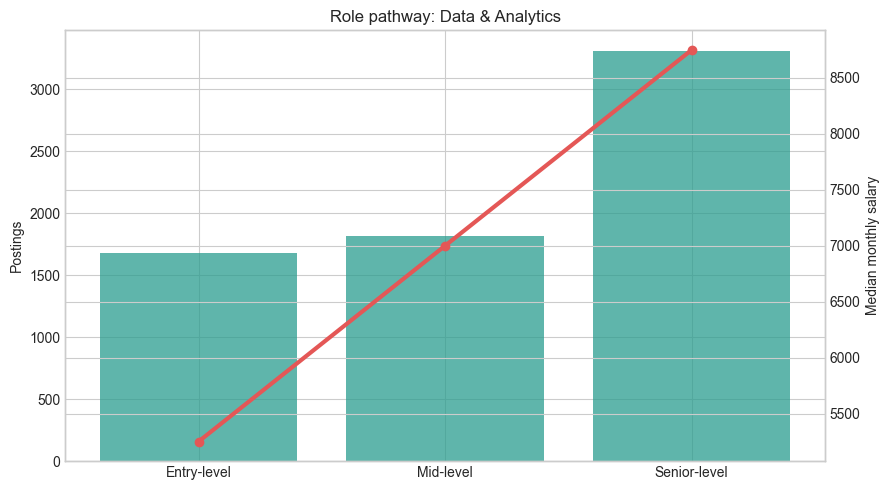

In [13]:
def show_role_pathway(role_family="Data & Analytics"):
    subset = pathway_summary[pathway_summary["role_family"].eq(role_family)].copy()
    order = ["Entry Level", "Mid Level", "Senior", "Manager & Lead"]
    subset["seniority"] = pd.Categorical(subset["seniority"], categories=order, ordered=True)
    subset = subset.sort_values("seniority")
    display(subset)

    if not subset.empty:
        fig, ax1 = plt.subplots(figsize=(9, 5))
        ax1.bar(subset["seniority"].astype(str), subset["postings"], color="#2a9d8f", alpha=0.75)
        ax1.set_ylabel("Postings")
        ax1.set_title(f"Role pathway: {role_family}")
        ax2 = ax1.twinx()
        ax2.plot(subset["seniority"].astype(str), subset["median_salary"], color="#e45756", marker="o", linewidth=3)
        ax2.set_ylabel("Median monthly salary")
        plt.tight_layout()
        plt.show()

show_role_pathway("Data & Analytics")


## 11. Notebook Dashboard Prototype

Run the cell below to filter the analysis by role family and seniority. If `ipywidgets` is installed in your Jupyter environment, dropdown filters will appear. Otherwise, call `career_dashboard()` manually with the role and seniority you want.


Postings: 1,036,725
Median monthly salary: $3,850
Average applications per vacancy: 1.7


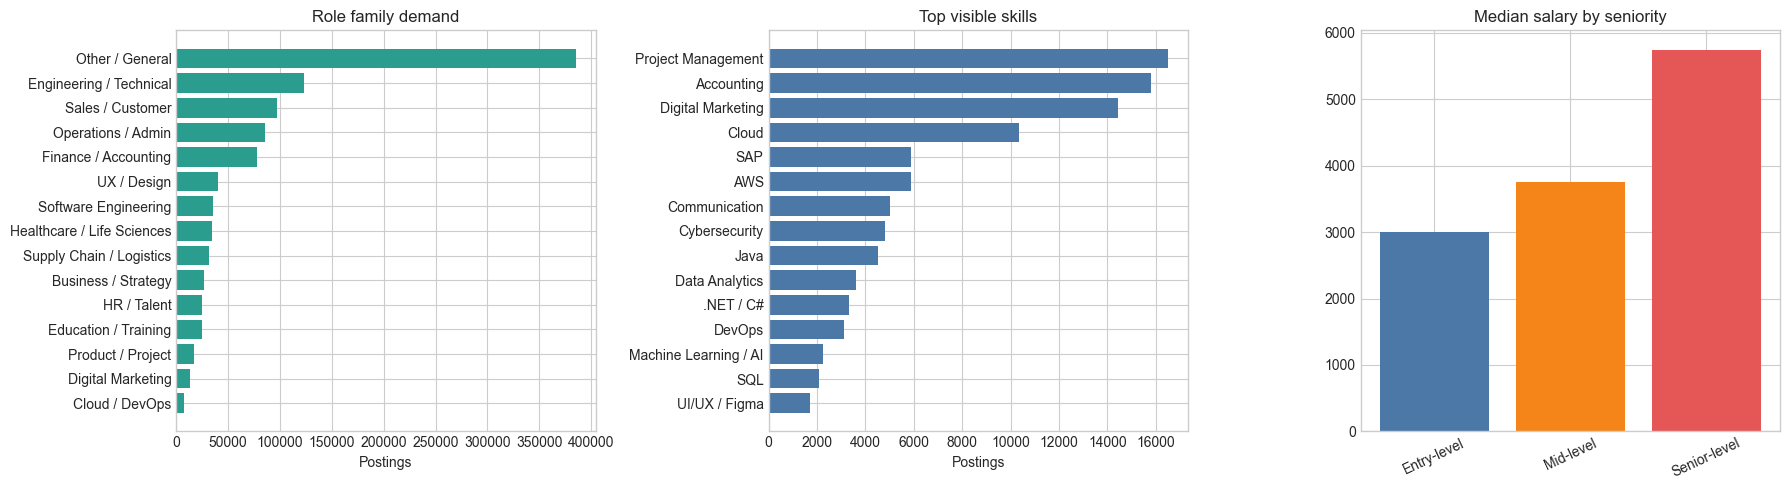

In [14]:
def career_dashboard(role_family="All", seniority="All", top_n=15):
    subset = df.copy()
    if role_family != "All":
        subset = subset[subset["role_family"].eq(role_family)]
    if seniority != "All":
        subset = subset[subset["seniority"].eq(seniority)]

    if subset.empty:
        print("No postings match the selected filters.")
        return

    subset_skills = (
        subset[subset["skill_count"] > 0]
        .explode("skills")
        .rename(columns={"skills": "skill"})
    )

    print(f"Postings: {len(subset):,}")
    print(f"Median monthly salary: ${subset['average_salary'].median():,.0f}")
    print(f"Average applications per vacancy: {subset['competition_per_vacancy'].mean():.1f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    roles = subset["role_family"].value_counts().head(top_n).sort_values()
    axes[0].barh(roles.index, roles.values, color="#2a9d8f")
    axes[0].set_title("Role family demand")
    axes[0].set_xlabel("Postings")

    if not subset_skills.empty:
        skills = subset_skills["skill"].value_counts().head(top_n).sort_values()
        axes[1].barh(skills.index, skills.values, color="#4c78a8")
        axes[1].set_title("Top visible skills")
        axes[1].set_xlabel("Postings")
    else:
        axes[1].text(0.5, 0.5, "No visible skill tags", ha="center", va="center")
        axes[1].set_axis_off()

    salary_by_level = subset.groupby("seniority")["average_salary"].median().reindex(["Entry Level", "Mid Level", "Senior", "Manager & Lead"])
    axes[2].bar(salary_by_level.index, salary_by_level.values, color=["#4c78a8", "#f58518", "#e45756"])
    axes[2].set_title("Median salary by seniority")
    axes[2].tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display

    role_options = ["All"] + sorted(df["role_family"].dropna().unique().tolist())
    seniority_options = ["All", "Entry Level", "Mid Level", "Senior", "Manager & Lead"]
    dashboard = widgets.interactive(
        career_dashboard,
        role_family=widgets.Dropdown(options=role_options, value="All", description="Role"),
        seniority=widgets.Dropdown(options=seniority_options, value="All", description="Seniority"),
        top_n=widgets.IntSlider(value=15, min=5, max=25, step=5, description="Top N"),
    )
    display(dashboard)
except Exception:
    career_dashboard(role_family="All", seniority="All", top_n=15)


## 12. Recommendations for Jobseekers and Career Switchers

The final table ranks skills using a simple employability score:

- **50% demand:** number of postings mentioning the skill.
- **30% salary:** median monthly salary.
- **20% accessibility:** share of postings classified as entry-level.

This is intentionally simple and explainable for presentation. Adjust the weights if the career-coaching strategy prioritises salary, beginner accessibility, or demand differently.


In [15]:
recommendations = skill_summary[[
    "skill", "postings", "median_salary", "entry_share", "senior_share", "employability_score"
]].copy()
recommendations["median_salary"] = recommendations["median_salary"].round(0).astype(int)
recommendations["entry_share"] = (recommendations["entry_share"] * 100).round(1)
recommendations["senior_share"] = (recommendations["senior_share"] * 100).round(1)
recommendations["employability_score"] = recommendations["employability_score"].round(3)
recommendations.head(15)


,skill,postings,median_salary,entry_share,senior_share,employability_score
18,Project Management,16498,7000,8.4,89.5,0.706
2,Accounting,15821,4000,43.5,41.6,0.635
10,Digital Marketing,14428,3750,51.1,26.6,0.605
5,Cloud,10331,5000,38.5,40.7,0.507
15,Machine Learning / AI,2235,8750,38.1,38.4,0.472
20,SAP,5871,6750,21.7,58.4,0.412
13,Java,4505,7500,13.7,63.2,0.385
7,Cybersecurity,4826,7000,17.6,59.0,0.380
9,DevOps,3103,8000,12.6,56.3,0.367
0,.NET / C#,3341,6700,30.4,44.1,0.362


In [16]:
def make_learning_message(row):
    skill = row["skill"]
    entry = row["entry_share"]
    salary = row["median_salary"]
    postings = row["postings"]
    if entry >= 30:
        access = "good entry-level accessibility"
    elif entry >= 15:
        access = "moderate entry-level accessibility"
    else:
        access = "mostly mid/senior positioning"
    return f"Learn {skill}: {postings:,} visible postings, median salary about ${salary:,.0f}, {access}."

for _, row in recommendations.head(10).iterrows():
    print("- " + make_learning_message(row))


- Learn Project Management: 16,498 visible postings, median salary about $7,000, mostly mid/senior positioning.
- Learn Accounting: 15,821 visible postings, median salary about $4,000, good entry-level accessibility.
- Learn Digital Marketing: 14,428 visible postings, median salary about $3,750, good entry-level accessibility.
- Learn Cloud: 10,331 visible postings, median salary about $5,000, good entry-level accessibility.
- Learn Machine Learning / AI: 2,235 visible postings, median salary about $8,750, good entry-level accessibility.
- Learn SAP: 5,871 visible postings, median salary about $6,750, moderate entry-level accessibility.
- Learn Java: 4,505 visible postings, median salary about $7,500, mostly mid/senior positioning.
- Learn Cybersecurity: 4,826 visible postings, median salary about $7,000, moderate entry-level accessibility.
- Learn DevOps: 3,103 visible postings, median salary about $8,000, mostly mid/senior positioning.
- Learn .NET / C#: 3,341 visible postings, media

## 13. Written Report Draft

Use this as the starting point for the README/PDF submission.

### Business case

- We built a career-guidance analytics prototype for jobseekers and career switchers in Singapore.
- The objective is to help users decide which skills to learn by comparing market demand, salary signals, entry-level accessibility, and role pathways.
- The dashboard supports career planning by translating raw job postings into skill recommendations and progression views.

### Data handling and process

- Loaded the Singapore jobs CSV with pandas and selected the columns needed for career guidance analysis.
- Parsed posting dates for monthly trend analysis.
- Standardised role families from job titles using transparent keyword rules.
- Classified postings into entry-level, mid-level, and senior-level using position level, minimum years of experience, and title keywords.
- Filtered salary analysis to monthly salaries with plausible values to keep comparisons meaningful.
- Extracted visible skill tags from job titles using a curated skill dictionary.
- Created demand, salary, competition, entry-share, and employability-score metrics.
- Main limitation: the data does not include full job descriptions, so skill counts are conservative.

### Dashboard / app walkthrough

- Overview view: role-family demand, seniority mix, and salary distribution.
- Skill view: top visible skills by demand and median salary.
- Trend view: monthly median salary by selected skills.
- Accessibility view: entry-level share by skill to support career switchers.
- Pathway view: entry, mid, and senior role summaries by role family.
- Interactive notebook dashboard: filters by role family, seniority, and number of top items.

### Challenges and learnings

- Skill extraction is limited by the absence of full job descriptions.
- Salary values need careful filtering because raw salary fields can include outliers.
- Entry Level opportunity is not the same as high demand; some high-paying skills are senior-heavy.
- A useful career-switcher dashboard should balance demand, pay, and accessibility rather than showing only one ranking.
